In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# Text Processing
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import hstack
# K-Means
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# Manga Reco
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import VBox
from sklearn.metrics.pairwise import cosine_similarity
# Sentiment
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from textblob import TextBlob
# Trend Detection
import datetime

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("mangadex_final.csv")

# tile + Description
df['text'] = (df['title'] + ' ' + df['description']).str.lower()

# remove punctuation or digits to be sure
df['text'] = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.lower()

df['text_clean'] = df['text'].astype(str).apply(
    lambda x: re.sub(r'[{}0-9]'.format(re.escape(string.punctuation)), ' ', x)
)

# remove stopwords
stop_words = ENGLISH_STOP_WORDS
df['text_clean'] = df['text_clean'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

# label
le_status = LabelEncoder()
le_lang = LabelEncoder()
le_demo = LabelEncoder()

df['status_encoded'] = le_status.fit_transform(df['status'])
df['language_encoded'] = le_lang.fit_transform(df['originalLanguage'])
df['demo_encoded'] = le_demo.fit_transform(df['publicationDemographic'])

## Decision Tree

In [5]:
# Status + language
X = df[['status_encoded', 'language_encoded']] 

# Text to Matrix
tfidf = TfidfVectorizer(max_features=300)
X_tfidf = tfidf.fit_transform(df['text_clean'])

# Final
X_final = hstack([X_tfidf, X]) 

# Demographic focus
y = df['demo_encoded']

In [6]:
# 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

In [7]:
# Create.train classifier
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [8]:
# Predict the demographic on the test set and show results
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4063906390639064

Confusion Matrix:
 [[ 164  377  131   40]
 [  87 1094  105  257]
 [ 117  429  236   75]
 [  60  862   98  312]]

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.23      0.29       712
           1       0.40      0.71      0.51      1543
           2       0.41      0.28      0.33       857
           3       0.46      0.23      0.31      1332

    accuracy                           0.41      4444
   macro avg       0.41      0.36      0.36      4444
weighted avg       0.42      0.41      0.38      4444



## K-Means

In [9]:
# Description to Matrix, Limit 500
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(df['text_clean'])

In [10]:
# Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_tfidf)

df['cluster'] = kmeans.labels_

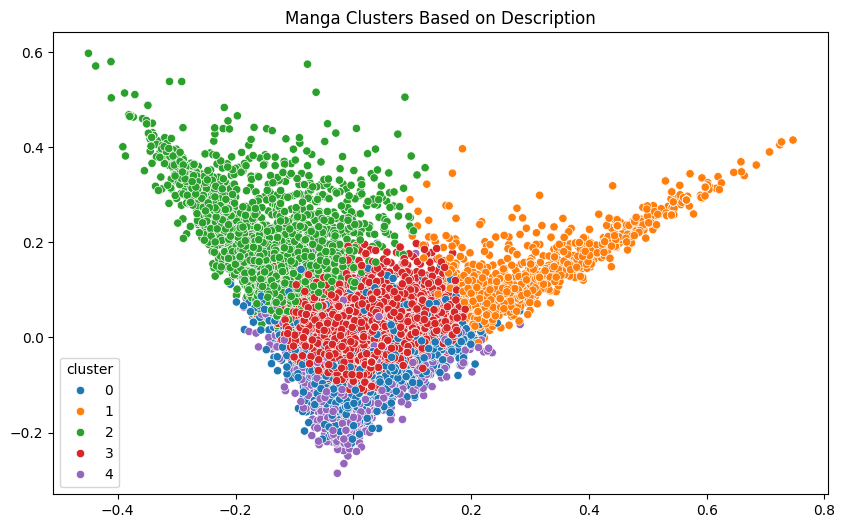

This scatter plot shows manga clustered based on the similarity of their descriptions.
Each color is a group formed by K-Means clustering.
Manga that are positioned closer together likely share similar themes/keywords in their decription.
PCA is used to reduce text features to 2 dimensions for visualization.


In [11]:
# vectors to 2D for plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette='tab10')
plt.title('Manga Clusters Based on Description')
plt.show()

print("This scatter plot shows manga clustered based on the similarity of their descriptions.")
print("Each color is a group formed by K-Means clustering.")
print("Manga that are positioned closer together likely share similar themes/keywords in their decription.")
print("PCA is used to reduce text features to 2 dimensions for visualization.")

## Manga Recommendation System

In [12]:
# Description to Matrix, Limit 500
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['text_clean'])

In [13]:
# Reco manga based on decription and demographic
def recommend_manga(title, df, tfidf_matrix, top_n=5, filter_by_demo=True):
    if title not in df['title'].values:
        print(f"'{title}' not found in the dataset.")
        return

    # Get title
    idx = df[df['title'] == title].index[0]
    # Cosine similarity
    cosine_sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    # Sort by what is similar
    sim_indices = cosine_sim.argsort()[::-1][1:top_n+10]

    # Manga with only same demo
    if filter_by_demo:
        original_demo = df.loc[idx, 'publicationDemographic']
        sim_indices = [i for i in sim_indices if df.loc[i, 'publicationDemographic'] == original_demo]

    # Get top recos
    sim_indices = sim_indices[:top_n]

    # Display Reco and info
    print(f"\nRecommendations similar to '{title}':\n")
    for i in sim_indices:
        print(f"Title: {df.loc[i, 'title']}")
        print(f"Description: {df.loc[i, 'description'][:150]}...")
        print(f"Demographic: {df.loc[i, 'publicationDemographic']} | Status: {df.loc[i, 'status']}")
        print("-" * 70)

In [14]:
# Input
title_widget = widgets.Text(
    value=' ', 
    placeholder='Type a manga title here...',
    description='Title:',
    layout=widgets.Layout(width='500px')
)

# Button
button = widgets.Button(
    description="Recommend",
    button_style='success',
    layout=widgets.Layout(width='200px')
)

# Output 
output = widgets.Output()

# Click 
def on_button_click(b):
    with output:
        clear_output()  # Clear old results
        recommend_manga(title_widget.value, df, tfidf_matrix, top_n=5)

button.on_click(on_button_click)

# Display 
display(VBox([title_widget, button, output]))

## Sentiment Analysis

In [17]:
nltk.download('vader_lexicon')

# Vader sentiment
sia = SentimentIntensityAnalyzer()

# Apply senti
df['sentiment_score'] = df['description'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to C:\Users\Laptop
[nltk_data]     Supplier PH\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


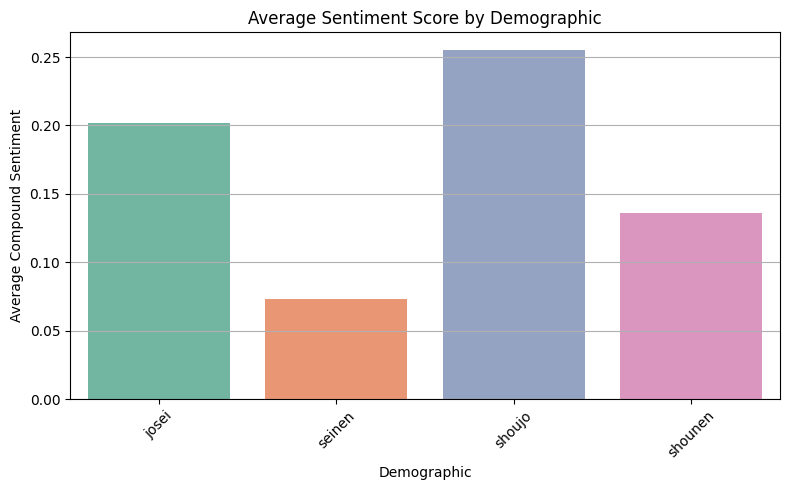

This chart shows the average sentiment of manga descriptions grouped by demographics.
Higher values (closer to +1) indicate more positive language. Lower values (closer to -1) reflect more negative tone.
This helps reveal which demographic tends to have more light or darker themes in their summaries.


In [18]:
# Drop rows
sentiment_demo = df.dropna(subset=['publicationDemographic', 'sentiment_score'])

# Group and compute sentiment
grouped = sentiment_demo.groupby('publicationDemographic')['sentiment_score'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='publicationDemographic', y='sentiment_score', data=grouped, palette='Set2')
plt.title("Average Sentiment Score by Demographic")
plt.ylabel("Average Compound Sentiment")
plt.xlabel("Demographic")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("This chart shows the average sentiment of manga descriptions grouped by demographics.")
print("Higher values (closer to +1) indicate more positive language. Lower values (closer to -1) reflect more negative tone.")
print("This helps reveal which demographic tends to have more light or darker themes in their summaries.")

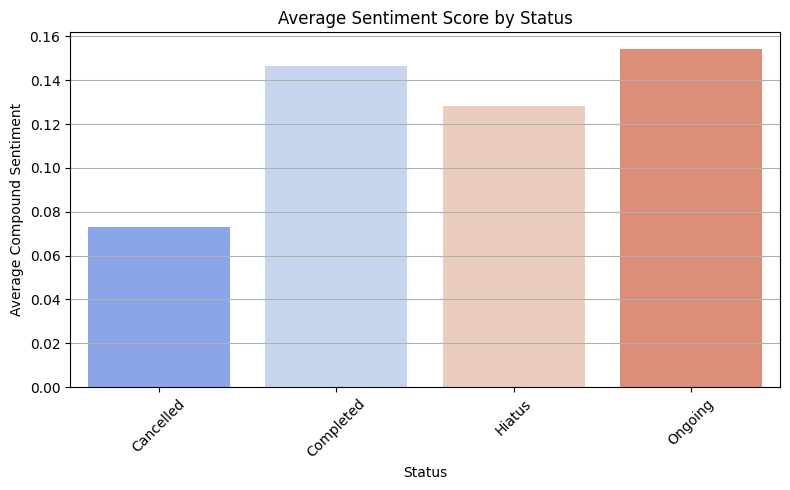

This chart shows the sentiment based on manga status.
It may indicate whether completed manga tend to have more positive summaries than ongoing or cancelled ones.


In [19]:
# Sentiment by status
status_group = df.dropna(subset=['status', 'sentiment_score']).groupby('status')['sentiment_score'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='status', y='sentiment_score', data=status_group, palette='coolwarm')
plt.title("Average Sentiment Score by Status")
plt.ylabel("Average Compound Sentiment")
plt.xlabel("Status")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("This chart shows the sentiment based on manga status.")
print("It may indicate whether completed manga tend to have more positive summaries than ongoing or cancelled ones.")

## Trend Detection

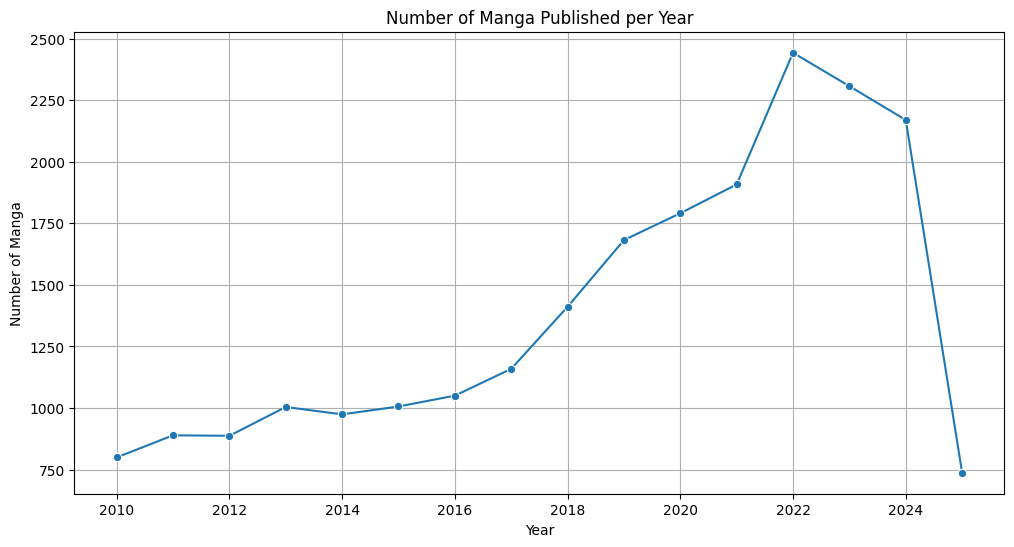

This chart shows the number of manga published each year. It helps identify industry trends, such as peak publication periods or declines.


In [20]:
# Convert 'year' column to datetime
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df_yearly = df.dropna(subset=['year'])

# Count manga per year
manga_per_year = df_yearly['year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=manga_per_year.index, y=manga_per_year.values, marker='o')
plt.title("Number of Manga Published per Year")
plt.xlabel("Year")
plt.ylabel("Number of Manga")
plt.grid(True)
plt.show()

print("This chart shows the number of manga published each year. It helps identify industry trends, such as peak publication periods or declines.")

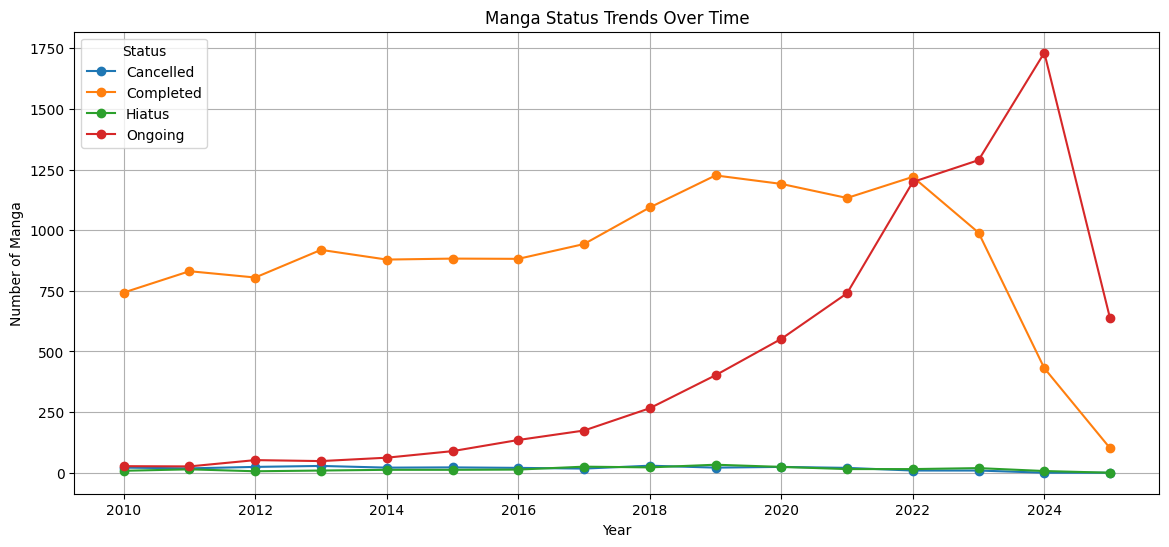

This chart shows how the status of manga has changed over time. It shows whether more manga are being finished or remain ongoing.


In [21]:
# Year + status
status_trend = df_yearly.groupby(['year', 'status']).size().unstack().fillna(0)

status_trend.plot(figsize=(14,6), marker='o')
plt.title("Manga Status Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Manga")
plt.grid(True)
plt.legend(title='Status')
plt.show()

print("This chart shows how the status of manga has changed over time. It shows whether more manga are being finished or remain ongoing.")

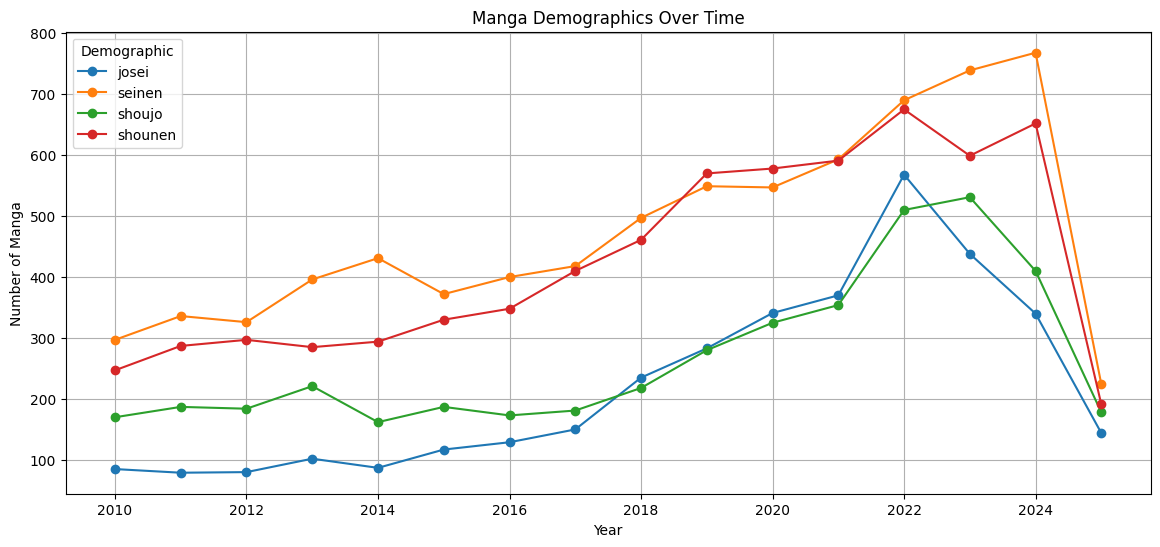

This chart shows the number of manga at different demographics over time. It reveals shifts in audience focus.
 Shounen = for young boys, often action or adventure.
 Shoujo = for young girls, typically romance and drama.
 Seinen = for adult men, mature or psychological themes.
 Josei = for adult women, realistic romance or life stories.



In [22]:
# Year + demographic
demo_trend = df_yearly.groupby(['year', 'publicationDemographic']).size().unstack().fillna(0)

demo_trend.plot(figsize=(14,6), marker='o')
plt.title("Manga Demographics Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Manga")
plt.grid(True)
plt.legend(title='Demographic')
plt.show()

print("This chart shows the number of manga at different demographics over time. It reveals shifts in audience focus.\n"
      " Shounen = for young boys, often action or adventure.\n"
      " Shoujo = for young girls, typically romance and drama.\n"
      " Seinen = for adult men, mature or psychological themes.\n"
      " Josei = for adult women, realistic romance or life stories.\n"
      )

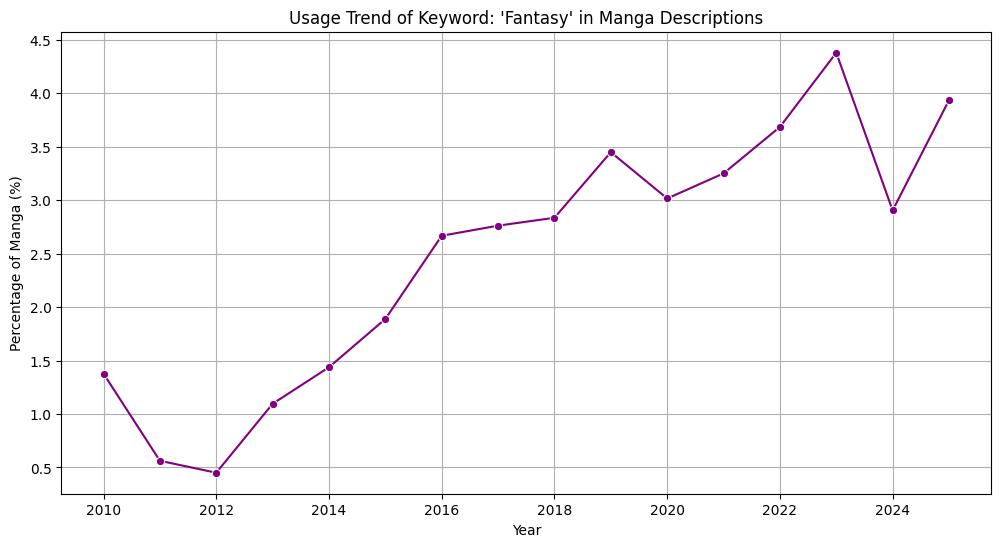

This chart shows how often the keyword 'fantasy' appears in manga descriptions by year. It reveals genre or theme popularity trends over time.
(Keywords can be changed)


In [23]:
# Keyword
keyword = "fantasy"

# Detect chosen keyword
df_yearly['has_keyword'] = df_yearly['text_clean'].str.contains(keyword, case=False, na=False)

# Group by year
keyword_trend = df_yearly.groupby('year')['has_keyword'].mean() * 100  # as percentage

plt.figure(figsize=(12,6))
sns.lineplot(x=keyword_trend.index, y=keyword_trend.values, marker='o', color='purple')
plt.title(f"Usage Trend of Keyword: '{keyword.capitalize()}' in Manga Descriptions")
plt.xlabel("Year")
plt.ylabel("Percentage of Manga (%)")
plt.grid(True)
plt.show()

print(f"This chart shows how often the keyword '{keyword}' appears in manga descriptions by year. It reveals genre or theme popularity trends over time.")
print("(Keywords can be changed)")